# Лаба 2 — Линейная, Ridge и Lasso регрессия (kc_house_data)

**Цель:** предсказать `price` и сравнить три модели: `LinearRegression`, `Ridge`, `Lasso`.

**Что делаем:** предобработка → стандартизация → выделение признаков → разбиение на train/test → обучение и сравнение моделей → визуализация и выводы.


In [ ]:
# === 1) Импорт библиотек ===
import io
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

print('Библиотеки готовы. Версии:')
import sys
print('Python:', sys.version)
print('Pandas:', pd.__version__)

Библиотеки готовы. Версии:
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas: 2.2.2


## Загрузка данных


In [ ]:
# === Загрузка данных из Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/kc_house_data.csv'

# Проверим наличие и загрузим датасет
import pandas as pd

try:
    df = pd.read_csv(csv_path, parse_dates=['date'])
    print('Файл успешно загружен с Google Диска!')
except FileNotFoundError:
    raise FileNotFoundError(f'Файл не найден по пути: {csv_path}')

print('Размерность датасета:', df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл успешно загружен с Google Диска!
Размерность датасета: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# csv_path = 'kc_house_data.csv'
# try:
#     df = pd.read_csv(csv_path, parse_dates=['date'])
# except FileNotFoundError:
#     raise FileNotFoundError('Не найден kc_house_data.csv. Загрузите файл (см. ячейку выше).')

# print('Размерность исходного датасета:', df.shape)
# display(df.head(3))
# display(df.info())
# display(df.describe().T.head(10))

## Предобработка данных
- Проверка пропусков и дублей
- Удаление низкоинформативных признаков (`id`, `date`, `zipcode`, `lat`, `long`, `sqft_basement`)
- Базовая очистка выбросов (правило 3σ + бизнес-правила)
- Базовая визуализация распределений

In [ ]:
# Копия датасета
df_clean = df.copy()

# Пропуски/дубликаты
print('Число пропусков по столбцам:')
display(df_clean.isna().sum())
print('Дубликаты:', df_clean.duplicated().sum())

# Удалим низкоинформативные признаки
drop_cols = ['id', 'date', 'zipcode', 'lat', 'long', 'sqft_basement']
for c in drop_cols:
    if c in df_clean.columns:
        df_clean.drop(columns=c, inplace=True)

print('После удаления столбцов:', df_clean.shape)

# Бизнес-правила по выбросам
before = df_clean.shape
if 'bedrooms' in df_clean.columns:
    df_clean = df_clean[df_clean['bedrooms'] <= 10]

# Функция 3σ для ряда столбцов
three_sigma_cols = [c for c in ['bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above',
                               'sqft_living15', 'sqft_lot15'] if c in df_clean.columns]
for col in three_sigma_cols:
    mu, sigma = df_clean[col].mean(), df_clean[col].std()
    df_clean = df_clean[(df_clean[col] - mu).abs() <= 3*sigma]

# Заодно отрежем верхний 1% цен, чтобы стабилизировать хвост
if 'price' in df_clean.columns:
    p99 = df_clean['price'].quantile(0.99)
    df_clean = df_clean[df_clean['price'] <= p99]

after = df_clean.shape
print('До очистки:', before, '| После очистки:', after)

Число пропусков по столбцам:


,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


Дубликаты: 0
После удаления столбцов: (21613, 15)
До очистки: (21613, 15) | После очистки: (20055, 15)


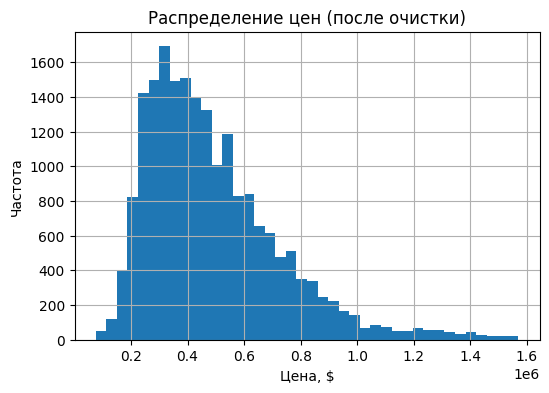

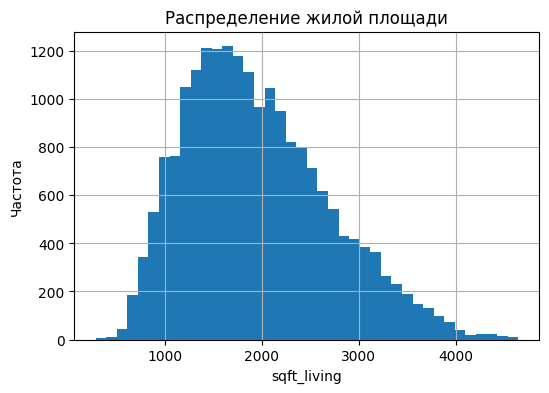

In [ ]:
# Гистограммы ключевых признаков
fig = plt.figure(figsize=(6,4))
df_clean['price'].hist(bins=40)
plt.title('Распределение цен (после очистки)')
plt.xlabel('Цена, $')
plt.ylabel('Частота')
plt.show()

if 'sqft_living' in df_clean.columns:
    fig = plt.figure(figsize=(6,4))
    df_clean['sqft_living'].hist(bins=40)
    plt.title('Распределение жилой площади')
    plt.xlabel('sqft_living')
    plt.ylabel('Частота')
    plt.show()

## Стандартизация
Масштабируем числовые признаки (кроме явных бинарных индикаторов, если они есть).

In [ ]:
num_features = [c for c in df_clean.columns if c != 'price' and pd.api.types.is_numeric_dtype(df_clean[c])]
print('Числовые признаки для масштабирования:', num_features)
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[num_features] = scaler.fit_transform(df_scaled[num_features])
display(df_scaled.describe().T.head(10))

Числовые признаки для масштабирования: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15']


,count,mean,std,min,25%,50%,75%,max
price,20055.0,4.891973e+05,238758.937137,75000.000000,315000.000000,437500.000000,608000.000000,1.570000e+06
bedrooms,20055.0,-1.185124e-16,1.000025,-3.774924,-0.370822,-0.370822,0.763879,7.572084e+00
bathrooms,20055.0,1.814001e-16,1.000025,-2.948706,-0.782118,-0.059922,0.662274,3.189960e+00
sqft_living,20055.0,-2.834376e-17,1.000025,-2.258505,-0.754141,-0.144263,0.628248,3.636977e+00
sqft_lot,20055.0,6.802503e-17,1.000025,-0.882935,-0.447017,-0.217382,0.033563,1.178204e+01
floors,20055.0,2.267501e-17,1.000025,-0.881689,-0.881689,-0.881689,0.971604,3.751543e+00
waterfront,20055.0,2.409220e-17,1.000025,-0.060857,-0.060857,-0.060857,-0.060857,1.643209e+01
view,20055.0,-5.952190e-17,1.000025,-0.276084,-0.276084,-0.276084,-0.276084,5.696808e+00
condition,20055.0,3.231189e-16,1.000025,-3.701996,-0.636235,-0.636235,0.896645,2.429525e+00
grade,20055.0,1.303813e-16,1.000025,-6.375764,-0.515909,-0.515909,0.460734,4.367304e+00


## Выделение новых признаков
- `price_per_sqft` = `price / sqft_living` - отражает ценность квадратного метра
- `house_age` = `2015 - yr_built` - учитывает, что новые дома обычно дороже
- `sqft_ratio` = `sqft_living / sqft_lot` - показатель плотности застройки

Сразу проверим корреляции с целевой переменной.

In [ ]:
df_fe = df_clean.copy()
if 'sqft_living' in df_fe.columns:
    df_fe['price_per_sqft'] = df_fe['price'] / df_fe['sqft_living']
if 'yr_built' in df_fe.columns:
    df_fe['house_age'] = 2015 - df_fe['yr_built']
if 'sqft_living' in df_fe.columns and 'sqft_lot' in df_fe.columns:
    df_fe['sqft_ratio'] = df_fe['sqft_living'] / df_fe['sqft_lot']

corr_cols = [c for c in ['price','price_per_sqft','house_age','sqft_ratio'] if c in df_fe.columns]
print('Корреляции с ценой для новых признаков:')
display(df_fe[corr_cols].corr().round(3))
display(df_fe.head(3))

Корреляции с ценой для новых признаков:


,price,price_per_sqft,house_age,sqft_ratio
price,1.000,0.542,-0.009,0.199
price_per_sqft,0.542,1.000,0.321,0.119
house_age,-0.009,0.321,1.000,-0.310
sqft_ratio,0.199,0.119,-0.310,1.000


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,yr_renovated,sqft_living15,sqft_lot15,price_per_sqft,house_age,sqft_ratio
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,1955,0,1340,5650,188.050847,60,0.208850
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,1951,1991,1690,7639,209.338521,64,0.354874
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,1933,0,2720,8062,233.766234,82,0.077000


## Разделение на Train/Test

In [ ]:
target = 'price'
df_model = df_fe.copy()
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16044, 17), (4011, 17), (16044,), (4011,))

## Обучение моделей: Linear, Ridge, Lasso
Сравним метрики R² и RMSE.


R² (коэффициент детерминации) — показывает, насколько хорошо модель объясняет данные (от 0 до 1).

RMSE (корень среднеквадратичной ошибки) — среднее отклонение предсказанной цены от реальной.

Зачем:
Чтобы понять, какая модель предсказывает точнее.
Например:
Высокий R² = модель объясняет большую часть вариации цен.
Низкий RMSE = ошибка мала → лучшее качество предсказания.

In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

models = {
    'LinearRegression': LinearRegression(),
    'Ridge(alpha=3)': Ridge(alpha=3),
    'Lasso(alpha=120)': Lasso(alpha=120)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        'Модель': name,
        'RMSE': round(rmse(y_test, y_pred), 2),
        'R²': round(r2_score(y_test, y_pred), 5)
    })

results_df = pd.DataFrame(results).sort_values(by='RMSE')
display(results_df)
best_model_name = results_df.iloc[0]['Модель']
print('Лучшая модель по RMSE:', best_model_name)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.833e+13, tolerance: 9.000e+10
  model = cd_fast.enet_coordinate_descent(


,Модель,RMSE,R²
2,Lasso(alpha=120),71326.58,0.91606
1,Ridge(alpha=3),71371.82,0.91595
0,LinearRegression,71373.31,0.91595


Лучшая модель по RMSE: Lasso(alpha=120)


## Коэффициенты моделей
Посмотрим на веса признаков для трёх моделей.

In [ ]:
lin = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=3).fit(X_train, y_train)
lasso = Lasso(alpha=120).fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Linear': lin.coef_,
    'Ridge(3)': ridge.coef_,
    'Lasso(120)': lasso.coef_
})
display(coef_df.round(4).sort_values(by='Linear', key=lambda s: s.abs(), ascending=False).head(20))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.833e+13, tolerance: 9.000e+10
  model = cd_fast.enet_coordinate_descent(


,Признак,Linear,Ridge(3),Lasso(120)
8,grade,27193.7077,27178.1380,26882.7254
1,bathrooms,13207.3172,13196.0363,12552.1571
6,view,12856.5288,12868.9261,12804.8743
16,sqft_ratio,12705.0171,12608.7545,6878.5972
5,waterfront,12059.8850,11361.7042,0.0000
7,condition,10801.6715,10796.2125,10514.0995
0,bedrooms,5937.2229,5932.4789,5618.4486
4,floors,-3178.9260,-3139.4358,-363.4089
14,price_per_sqft,1581.7708,1581.8768,1584.8182
2,sqft_living,222.6250,222.6664,224.9589


## Визуализация предсказаний и остатков
Построим графики для лучшей модели.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.833e+13, tolerance: 9.000e+10
  model = cd_fast.enet_coordinate_descent(


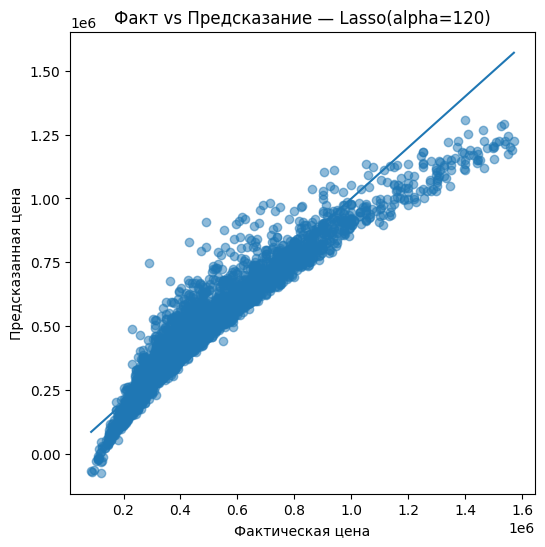

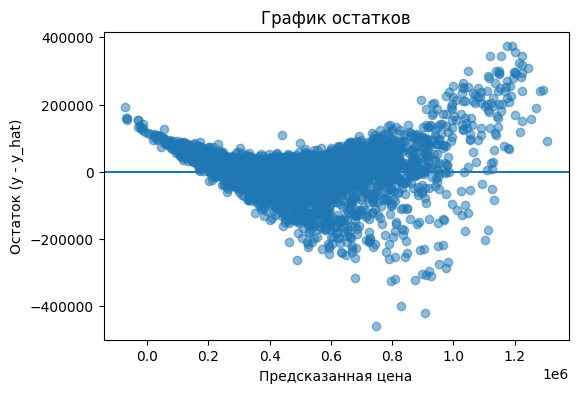

In [ ]:
best_name = best_model_name
best_model = models[best_name]

# Повторно обучим (на всякий случай) и получим предсказания
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Фактические vs Предсказанные
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Факт vs Предсказание — {best_name}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

# Остатки
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel('Предсказанная цена')
plt.ylabel('Остаток (y - y_hat)')
plt.title('График остатков')
plt.show()

## Выводы
- Сравнили три линейные модели: **LinearRegression**, **Ridge**, **Lasso**.
- Посмотрели метрики **R²** и **RMSE**, а также коэффициенты.
- **Ridge** использует L2-регуляризацию (сжимает веса к нулю), **Lasso** — L1-регуляризацию (обнуляет часть весов и делает отбор признаков).
